# 05 — Decisioning and Explainability

Inputs: `data/X_train.csv`, `data/X_val.csv`, `data/y_train.csv`, `data/y_val.csv`, `data/features.csv` 

## 0. Imports

In [2]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'font.size': 9,
})
RANDOM_STATE = 42

X_train = pd.read_csv('../data/X_train.csv')
X_val   = pd.read_csv('../data/X_val.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/y_val.csv').squeeze()

model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train, y_train)
pd_score = model.predict_proba(X_val)[:, 1]

print(f'Validation applicants: {len(X_val):,}')
print(f'Mean predicted PD: {pd_score.mean():.4f}')
print(f'Observed default rate: {y_val.mean():.4f}')

Validation applicants: 10,000
Mean predicted PD: 0.0827
Observed default rate: 0.0810


## 1. Risk Bands

A PD score is not itself a decision. We map it to one using two thresholds: applicants below a low cut-off are approved automatically, those above a high cut-off are declined, and the band in between is sent for manual review. We do not have LGD or EAD, meaning we cannot calculate the loss on a default. However, we can start with an initial guess of a split and see how it partitions the data before varying these bands and seeing how many defaulters we let through.

In [2]:
APPROVE_BELOW = 0.10   
DECLINE_AT    = 0.30   


def assign_band(p):
    return np.where(p < APPROVE_BELOW, '1_APPROVE',
           np.where(p < DECLINE_AT,    '2_REVIEW', '3_DECLINE'))

bands = assign_band(pd_score)
book = pd.DataFrame({'band': bands, 'pd': pd_score, 'defaulted': y_val.values})

summary = book.groupby('band').agg(
    applicants=('defaulted', 'size'),
    pct_of_book=('defaulted', lambda s: 100 * len(s) / len(book)),
    observed_default_pct=('defaulted', lambda s: 100 * s.mean()),
    defaulters=('defaulted', 'sum'),
).round(2)
print(summary.to_string())

total_def = int(y_val.sum())
approved = book[book.band == '1_APPROVE']
declined = book[book.band == '3_DECLINE']
print(f'\nApproved-book default rate:           {100*approved.defaulted.mean():.2f}%  '
      f'(vs {100*y_val.mean():.2f}% portfolio)')
print(f'Share of all defaulters in DECLINE:   {100*declined.defaulted.sum()/total_def:.1f}%')
print(f'Auto-decision rate (approve+decline): {100*(bands != "2_REVIEW").mean():.1f}%  '
      f'(review: {100*(bands == "2_REVIEW").mean():.1f}%)')

           applicants  pct_of_book  observed_default_pct  defaulters
band                                                                
1_APPROVE        8236        82.36                  2.53         208
2_REVIEW         1054        10.54                 18.31         193
3_DECLINE         710         7.10                 57.61         409

Approved-book default rate:           2.53%  (vs 8.10% portfolio)
Share of all defaulters in DECLINE:   50.5%
Auto-decision rate (approve+decline): 89.5%  (review: 10.5%)


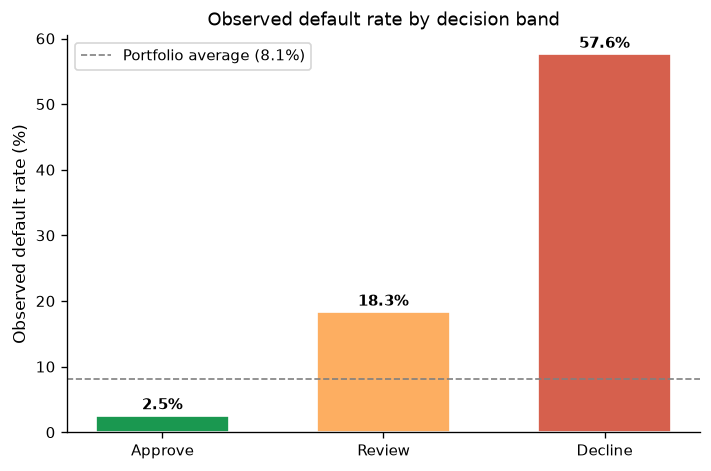

In [3]:
order = ['1_APPROVE', '2_REVIEW', '3_DECLINE']
colors = ['#1a9850', '#fdae61', '#d6604d']
rates = [100 * book.loc[book.band == b, 'defaulted'].mean() for b in order]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Approve', 'Review', 'Decline'], rates, color=colors, edgecolor='white', width=0.6)
ax.axhline(100 * y_val.mean(), color='gray', linestyle='--', lw=1,
           label=f'Portfolio average ({100*y_val.mean():.1f}%)')
for i, r in enumerate(rates):
    ax.text(i, r + 1, f'{r:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Observed default rate (%)')
ax.set_title('Observed default rate by decision band')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Individuals with a PD < 0.1 are APPROVED, they only have a default rate of 2.5%.

In [5]:
print(f"{'approve if PD <':>16}{'approval rate':>15}{'approved bad rate':>19}{'% defaulters declined':>24}")
for c in [0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30]:
    accept = pd_score < c
    appr   = accept.mean() * 100
    abad   = y_val.values[accept].mean() * 100
    caught = y_val.values[~accept].sum() / y_val.sum() * 100
    print(f"{c:>16.2f}{appr:>14.1f}%{abad:>17.2f}%{caught:>23.1f}%")

 approve if PD <  approval rate  approved bad rate   % defaulters declined
            0.03          58.7%             1.19%                   91.4%
            0.05          70.8%             1.58%                   86.2%
            0.07          76.9%             2.00%                   81.0%
            0.10          82.4%             2.53%                   74.3%
            0.15          87.2%             3.15%                   66.0%
            0.20          89.8%             3.65%                   59.5%
            0.30          92.9%             4.32%                   50.5%


The chart above applies the fixed 3-band policy (approve < 0.10, review 0.10–0.30, decline ≥ 0.30), so its APPROVE bar covers only applicants below 0.10. The table below instead sweeps a single accept/decline cut-off, so each row reports the outcome if we approved everyone below that PD.

We can derive a strategy from this table. If we want to auto-approve a specific percent or control the bad rate percent we can adjust the cutoff accordingly. For example we can see that an 80% approval target implies a ~0.08 cutoff at a 2.3% approved-book bad rate, and a 3% bad-rate ceiling implies a ~0.14 cutoff at 86% approval.

**Objective 9: Explain at least one high-risk applicant prediction**

Because the model is a logistic regression, a prediction is just a weighted sum of the applicant's features passed through a sigmoid. So to explain any one decision, I take their predicted PD and break it back into the contribution each feature made. Sorting these contributions produces a ranked list of factors pushing the applicant toward default (positive) and repayment (negative). 

In [5]:
mask = (y_val.values == 1) & (pd_score >= 0.30) & (pd_score <= 0.55)
idx = int(pd.Series(pd_score)[mask].idxmax())

contributions = model.coef_[0] * X_val.iloc[idx].values
logit = contributions.sum() + model.intercept_[0]
pd_reconstructed = 1 / (1 + np.exp(-logit))

reason_codes = (
    pd.DataFrame({
        'feature': X_val.columns,
        'std_value': X_val.iloc[idx].values,
        'logodds_contribution': contributions,
    })
    .sort_values('logodds_contribution', ascending=False)
)

print(f'PD: {pd_score[idx]:.4f}  (reconstructed: {pd_reconstructed:.4f})')
print(f'Actually defaulted: {int(y_val[idx])}')
print(reason_codes.head(6).to_string(index=False))   
print(reason_codes.tail(3).to_string(index=False))  

PD: 0.5458  (reconstructed: 0.5458)
Actually defaulted: 1
            feature  std_value  logodds_contribution
  ANNUITY_TO_INCOME   1.209756              1.763053
BUREAU_INQUIRIES_6M   2.716401              0.924428
BUREAU_DPD_60_COUNT   2.074217              0.661967
         AMT_CREDIT   4.143794              0.264209
   CREDIT_TO_INCOME   2.726319              0.232016
        TERM_MONTHS   1.578883              0.140644
                                feature  std_value  logodds_contribution
MONTHS_SINCE_DELINQ_BINNED_older_25_60m        1.0             -0.337638
                    HOME_OWNERSHIP_Rent        1.0             -0.387018
             EMPLOYMENT_STATUS_Salaried        1.0             -0.489483


We picked an individual who would be rejected by our previous 3-band policy, being flagged as high-risk. `ANNUITY_TO_INCOME` increased the log-odds of defaulting by the largest quantity. 

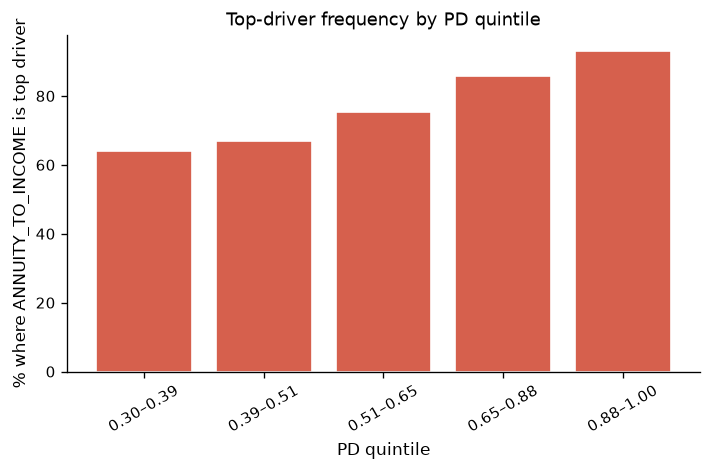

In [7]:
PD_THRESHOLD = 0.30
driver_feature = next(c for c in ['ANNUITY_TO_INCOME', 'annuity_to_income'] if c in X_val.columns)
driver_col_idx = list(X_val.columns).index(driver_feature)

hr_idx = np.where(pd_score > PD_THRESHOLD)[0]
is_top = [int(np.argmax(model.coef_[0] * X_val.iloc[i].values) == driver_col_idx) for i in hr_idx]

df = pd.DataFrame({'pd': pd_score[hr_idx], 'is_top_driver': is_top})
df['pd_bin'] = pd.qcut(df['pd'], q=5, duplicates='drop')
pct_top = df.groupby('pd_bin')['is_top_driver'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([f'{iv.left:.2f}–{iv.right:.2f}' for iv in pct_top.index], pct_top.values,
       color='#d6604d', edgecolor='white')
ax.set_xlabel('PD quintile')
ax.set_ylabel(f'% where {driver_feature} is top driver')
ax.set_title('Top-driver frequency by PD quintile')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

I extended the single-applicant case above, checking across every high-risk applicant (PD > 0.30). The pattern is not a one-off. ANNUITY_TO_INCOME is the top driver for roughly 65% of applicants in the lowest high-risk quintile (PD 0.30–0.39), and that climbs steadily through each quintile to over 90% in the highest (PD 0.88–1.00). This isn't necessarily a modelling error. Annuity-to-income is a debt-servicing measure, and it's plausible that overleveraging really is the dominant driver of default at the riskiest end of the book. But it does mean the model's explanations narrow sharply for the applicants most likely to be declined.

## 2. Conclusion

The PD score becomes a lending decision through the two-threshold policy above: applicants below 0.10 are approved automatically, those above 0.30 are declined, and the 10.5% in between go to manual review. On the validation set this produces an approved-book default rate of 2.53% against a portfolio average of 8.10%, and the decline band alone (7.1% of applicants) captures just over half of all defaulters. Roughly 9 in 10 applicants are auto-decisioned either way, which is the practical payoff of a calibrated PD score over judgment alone.

The same pattern shows up at every level of this model. `ANNUITY_TO_INCOME` has the largest coefficient by a wide margin, and it's the leading driver behind the example applicant above. Across every applicant with PD > 0.30 it's the top-ranked driver for 65% of the lowest high-risk quintile, rising to 90% in the highest. The model relies on affordability more than any other signal, and relies on it harder the riskier the applicant looks.

A gradient-boosted model (XGBoost, LightGBM) would likely improve raw discrimination further, consistent with the literature on PD models, though typically by a modest margin and at a real cost to the transparency this brief asks for. Any such model would also need explicit post-hoc calibration before its probabilities could be trusted for decisioning. Additionally, redoing this project there would be 2 crucial statistics very commonly used with credit data to explore:

**Weight of Evidence**

 The approach we would adopt with more time replaces raw feature values with their Weight of Evidence (WoE). Each predictor is first binned (continuous variables into quantile groups, categoricals by their levels), and each bin is assigned its WoE, the log-ratio of the proportion of non-defaulters to defaulters falling in it: WoE = ln(% non-events / % events). The model is then fit on these WoE values rather than the original variables. This brings several advantages directly relevant to our problem. It handles missing data, as a missing bin (e.g. our thin-file applicants) simply becomes its own category with its own WoE, removing the need for imputation entirely. It needs no one-hot encoding, because categoricals are already mapped to a single numeric WoE. And critically, because WoE is itself a log-odds quantity, it linearises each predictor's relationship with the log-odds of default, exactly the functional form logistic regression assumes.

**Information Value**
 
 Standard univariate feature-screening statistic in credit-risk modelling. Measures how strongly the distribution of good applicants differs from the distribution of bad applicants across its bins, constructed using WoE. A feature whose good and bad applicants are distributed identically carries no information and scores near 0, the more the distributions diverge, the higher the IV. Used as a screening step to rank predictors and drop those that are uninformative before modelling.